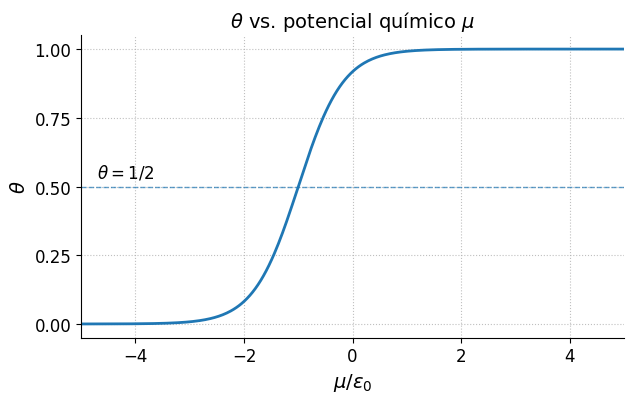

In [2]:
# ============================================
#  Cobertura θ(μ) para el modelo de adsorción
#  Versión "paper ready" para LaTeX
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros físicos (ajústalos si quieres) ---
kB   = 1.380649e-23      # J/K
T    = 300.0             # K
eps0 = 1.0e-20           # J

beta = 1.0 / (kB * T)

# Rango de μ (en unidades de epsilon_0)
mu_min = -5.0 * eps0
mu_max =  5.0 * eps0
num_points = 400

mu = np.linspace(mu_min, mu_max, num_points)
mu_red = mu / eps0  # μ / ε0

x = beta * (eps0 + mu)
theta = np.exp(x) / (1.0 + np.exp(x))

# --- Figura ---
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

fig, ax = plt.subplots(figsize=(6.5, 4.2))

# Curva principal
ax.plot(mu_red, theta, linewidth=2)

# Límites y ticks agradables
ax.set_xlim(mu_red.min(), mu_red.max())
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])

# Etiquetas y título
ax.set_xlabel(r'$\mu / \epsilon_0$')
ax.set_ylabel(r'$\theta$')
ax.set_title(r'$\theta$ vs. potencial químico $\mu$')

# Línea guía en θ = 1/2
ax.axhline(0.5, linestyle='--', linewidth=1, alpha=0.7)
ax.text(mu_red.min() + 0.3, 0.52,
        r'$\theta = 1/2$',
        va='bottom', ha='left')

# Mejoras estéticas en los ejes
ax.grid(True, which='both', linestyle=':', linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()

# --- Guardar en archivo (para LaTeX) ---
plt.savefig("theta_vs_mu.png", dpi=300, bbox_inches="tight")

plt.show()


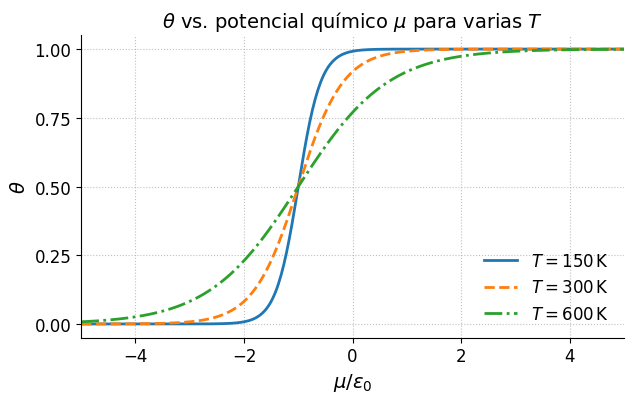

In [4]:
# ============================================
#  Cobertura θ(μ) para varias temperaturas T
#  Versión "paper ready" para LaTeX
# ============================================

import numpy as np
import matplotlib.pyplot as plt

kB   = 1.380649e-23      # J/K
eps0 = 1.0e-20           # J

# Temperaturas a comparar
T_list = [150.0, 300.0, 600.0]   # K

mu_min = -5.0 * eps0
mu_max =  5.0 * eps0
num_points = 400

mu = np.linspace(mu_min, mu_max, num_points)
mu_red = mu / eps0  # μ / ε0

# --- Estilo general ---
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

fig, ax = plt.subplots(figsize=(6.5, 4.2))

# --- Curvas para cada T ---
linestyles = ['-', '--', '-.']  # sólo cambiamos estilo de línea

for T, ls in zip(T_list, linestyles):
    beta = 1.0 / (kB * T)
    x = beta * (eps0 + mu)
    theta = np.exp(x) / (1.0 + np.exp(x))
    ax.plot(mu_red, theta, linestyle=ls, linewidth=2,
            label=fr'$T = {T:.0f}\,\mathrm{{K}}$')

# --- Acabado de la figura ---
ax.set_xlim(mu_red.min(), mu_red.max())
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])

ax.set_xlabel(r'$\mu / \epsilon_0$')
ax.set_ylabel(r'$\theta$')
ax.set_title(r'$\theta$ vs. potencial químico $\mu$ para varias $T$')

ax.grid(True, which='both', linestyle=':', linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

# Leyenda limpia
leg = ax.legend(frameon=False, loc='lower right')

plt.tight_layout()

# Guardar para LaTeX
plt.savefig("theta_vs_mu_multiT.png", dpi=300, bbox_inches="tight")

plt.show()


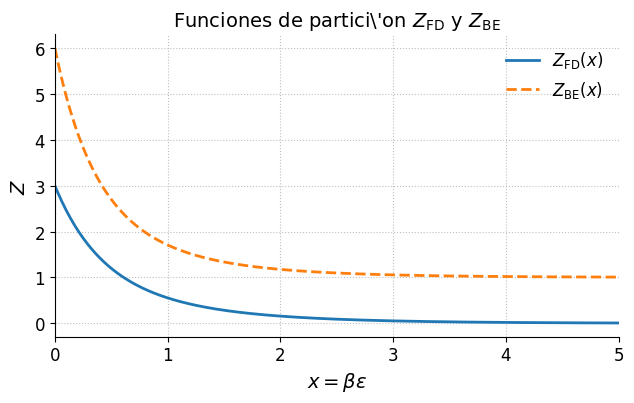

In [5]:
# ============================================
#  Problema 2: Z_FD(x) y Z_BE(x)
#  (x = beta * epsilon) - Figura "paper ready"
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# Variable adimensional x = beta * epsilon
x_min, x_max = 0.0, 5.0
num_points = 400
x = np.linspace(x_min, x_max, num_points)

# Funciones de partición en términos de x
Z_FD = np.exp(-x) + np.exp(-2*x) + np.exp(-3*x)
Z_BE = 1 + np.exp(-x) + 2*np.exp(-2*x) + np.exp(-3*x) + np.exp(-4*x)

# Estilo general
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

fig, ax = plt.subplots(figsize=(6.5, 4.2))

ax.plot(x, Z_FD, linewidth=2, linestyle='-',  label=r'$Z_{\mathrm{FD}}(x)$')
ax.plot(x, Z_BE, linewidth=2, linestyle='--', label=r'$Z_{\mathrm{BE}}(x)$')

ax.set_xlim(x_min, x_max)
ax.set_xlabel(r'$x = \beta \epsilon$')
ax.set_ylabel(r'$Z$')
ax.set_title(r'Funciones de partici\'on $Z_{\mathrm{FD}}$ y $Z_{\mathrm{BE}}$')

ax.grid(True, which='both', linestyle=':', linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig("Z_FD_BE_vs_x.png", dpi=300, bbox_inches="tight")
plt.show()


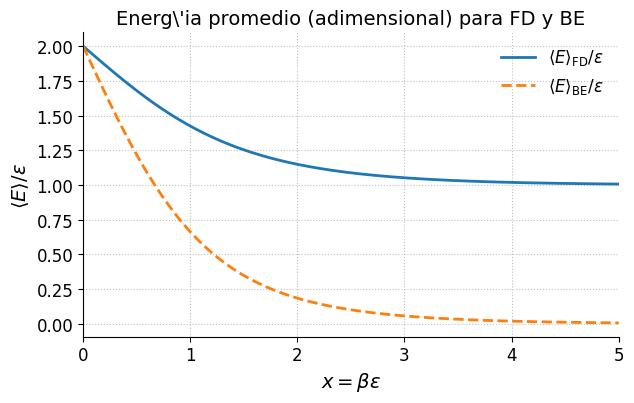

In [6]:
# ============================================
#  Problema 2: <E>(x)/epsilon para FD y BE
#  (x = beta * epsilon) - Figura "paper ready"
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# Variable adimensional x = beta * epsilon
x_min, x_max = 0.0, 5.0
num_points = 400
x = np.linspace(x_min, x_max, num_points)

# ----- Caso Fermi-Dirac -----
# Energías en unidades de epsilon
E_FD = np.array([1.0, 2.0, 3.0])     # E/epsilon
# Z_FD(x)
Z_FD = np.exp(-x*E_FD[0]) + np.exp(-x*E_FD[1]) + np.exp(-x*E_FD[2])
# <E>/epsilon (trabajamos todo adimensional)
E_avg_FD = (
    E_FD[0]*np.exp(-x*E_FD[0]) +
    E_FD[1]*np.exp(-x*E_FD[1]) +
    E_FD[2]*np.exp(-x*E_FD[2])
) / Z_FD

# ----- Caso Bose-Einstein -----
# Energías en unidades de epsilon y sus multiplicidades
E_BE   = np.array([0.0, 1.0, 2.0, 2.0, 3.0, 4.0])  # E/epsilon
# Z_BE(x)
Z_BE = np.sum(np.exp(-x[:, None] * E_BE[None, :]), axis=1)
# <E>/epsilon
E_avg_BE = np.sum(
    E_BE[None, :] * np.exp(-x[:, None] * E_BE[None, :]),
    axis=1
) / Z_BE

# Estilo general
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

fig, ax = plt.subplots(figsize=(6.5, 4.2))

ax.plot(x, E_avg_FD, linewidth=2, linestyle='-',  label=r'$\langle E \rangle_{\mathrm{FD}} / \epsilon$')
ax.plot(x, E_avg_BE, linewidth=2, linestyle='--', label=r'$\langle E \rangle_{\mathrm{BE}} / \epsilon$')

ax.set_xlim(x_min, x_max)
ax.set_xlabel(r'$x = \beta \epsilon$')
ax.set_ylabel(r'$\langle E \rangle / \epsilon$')
ax.set_title(r'Energ\'ia promedio (adimensional) para FD y BE')

ax.grid(True, which='both', linestyle=':', linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig("Eavg_FD_BE_vs_x.png", dpi=300, bbox_inches="tight")
plt.show()


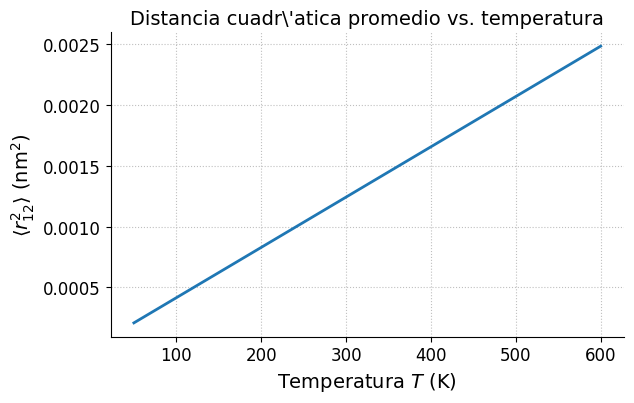

In [7]:
# ============================================
#  Problema 3:
#  <r12^2> vs T para un K fijo
#  (figura "paper ready")
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros físicos (puedes ajustarlos) ---
kB = 1.380649e-23      # J/K
K  = 10.0              # N/m, constante elástica de ejemplo

# Rango de temperatura
T_min = 50.0           # K
T_max = 600.0          # K
num_points = 400

T = np.linspace(T_min, T_max, num_points)

# <r12^2> = 3 k_B T / K
r2_avg = 3.0 * kB * T / K   # unidades: m^2

# Para visualizar más cómodo, usamos nm^2 (1 nm = 1e-9 m)
r2_avg_nm2 = r2_avg / (1e-9 ** 2)

# Estilo general
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

fig, ax = plt.subplots(figsize=(6.5, 4.2))

ax.plot(T, r2_avg_nm2, linewidth=2)

ax.set_xlabel(r'Temperatura $T$ (K)')
ax.set_ylabel(r'$\langle r_{12}^{2} \rangle$ (nm$^{2}$)')
ax.set_title(r'Distancia cuadr\'atica promedio vs. temperatura')

ax.grid(True, which='both', linestyle=':', linewidth=0.8, alpha=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("r2_vs_T.png", dpi=300, bbox_inches="tight")
plt.show()
